In [1]:
import numpy as np
import cvxpy as cp
import flexitroid.aggregations.aggregator as agg
import flexitroid.problems.signal_tracker as signal_tracker
from flexitroid.utils.population_generator import PopulationGenerator
from importlib import reload

import matplotlib.pyplot as plt


In [16]:
T = 48
populations = [PopulationGenerator(T, e1s_count=10), PopulationGenerator(T, e1s_count=10) ]
aggregators = [agg.Aggregator(pop) for pop in populations]
c =  -np.sin(np.arange(T)/T*2*np.pi)
solutions = np.array([aggregators[0].solve_constrainted_lp(c, tightness=3).solution, aggregators[1].solve_constrainted_lp(c, tightness=5).solution ])
con1 = np.ones(T)*np.max(solutions[0])
con2 = np.ones(T)*np.max(solutions[1])

plt.plot(con1)
plt.plot(con2)
plt.plot(solutions[0])
plt.plot(solutions[1])

AttributeError: 'NoneType' object has no attribute 'size'

converged


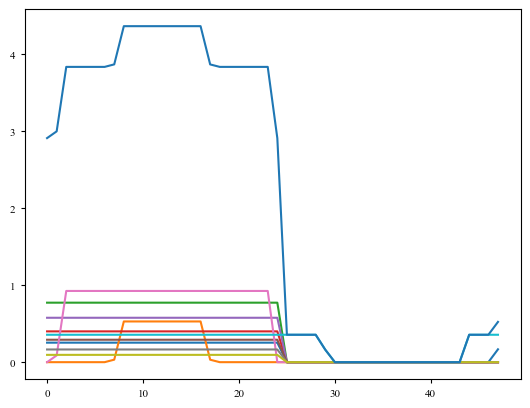

In [43]:
i = 0
A1 = aggregators[i]
dissage = A1.disaggregate(solutions[i])

plt.plot(dissage.T)
plt.plot(solutions[i])
# plt.plot(np.sum(dissage, axis=0))

In [27]:
i

0

In [7]:
cluster1

NameError: name 'cluster1' is not defined

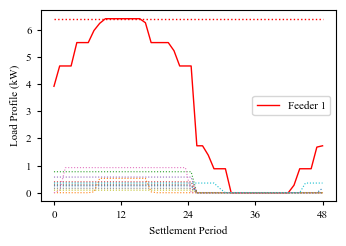

In [57]:
# Set global plot parameters
i=1
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "Times New Roman",
        "font.size": 8,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
)

plt.rc("text", usetex=False)
plt.rc("font", family="serif")
plt.rc("axes", labelsize=8)
plt.rc("xtick", labelsize=8)
plt.rc("ytick", labelsize=8)
plt.rc("legend", fontsize=8)

# Time axis
time = np.linspace(0, 48,48)  # 24 points from 0 to 24

# ---------------------------------------------------------------------
# Replace these with actual data
cluster1 = solutions[0]
cluster2 = solutions[1]
aggregated = np.sum(solutions, axis=0)
price = c
# ---------------------------------------------------------------------
con1 = np.ones(T)*np.max(solutions[i])

fig, ax1 = plt.subplots(figsize=(3.5, 2.5))

ax1.plot(time, con1, color='red', linestyle=':', linewidth=1)
# Primary axis: consumption
ax1.plot(time, solutions[i], color='red', linestyle='-', linewidth=1,label=f'Feeder {2-i}')
# ax1.plot(time, con2, color='red', linestyle=':', linewidth=1)
for dev in dissage:
    ax1.plot(time, dev, linestyle=':', linewidth=.8)

ax1.set_xlabel('Settlement Period')
ax1.set_ylabel('Load Profile (kW)')
ax1.set_xticks(np.arange(0,60,12))

# # Create a secondary axis for price
# ax2 = ax1.twinx()
# ax2.plot(time, price, color='black', linestyle='-', label='Cost')
# ax2.set_ylabel('Energy Cost (£/kWh)')
# ax2.set_ybound([-1,2.5])
# lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
ax1.legend()
plt.tight_layout()
plt.savefig("disaggregated.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

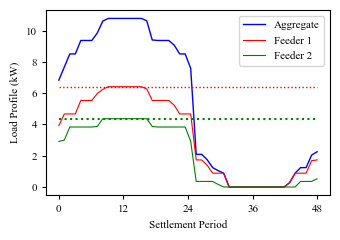

In [54]:
# Set global plot parameters
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "Times New Roman",
        "font.size": 10,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
)

plt.rc("text", usetex=False)
plt.rc("font", family="serif")
plt.rc("axes", labelsize=8)
plt.rc("xtick", labelsize=8)
plt.rc("ytick", labelsize=8)
plt.rc("legend", fontsize=8)

# Time axis
time = np.linspace(0, 48,48)  # 24 points from 0 to 24

# ---------------------------------------------------------------------
# Replace these with actual data
cluster1 = solutions[0]
cluster2 = solutions[1]
aggregated = np.sum(solutions, axis=0)
price = c
# ---------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(3.5, 2.5))

# Primary axis: consumption
ax1.plot(time, aggregated, color='blue', linestyle='-', linewidth=1, label='Aggregate')
ax1.plot(time, cluster2, color='red', linestyle='-', linewidth=.8,label='Feeder 1')
ax1.plot(time, con2, color='red', linestyle=':', linewidth=1)
ax1.plot(time, cluster1, color='green', linestyle='-', linewidth=.8, label='Feeder 2')
ax1.plot(time, con1, color='green', linestyle=':')
ax1.set_xlabel('Settlement Period')
ax1.set_ylabel('Load Profile (kW)')
ax1.set_xticks(np.arange(0,60,12))

# # Create a secondary axis for price
# ax2 = ax1.twinx()
# ax2.plot(time, price, color='black', linestyle='-', label='Cost')
# ax2.set_ylabel('Energy Cost (£/kWh)')
# ax2.set_ybound([-1,2.5])
# lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
ax1.legend()
plt.tight_layout()
plt.savefig("aggregated.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()